In [1]:
import pandas as pd

df = pd.read_csv('Resume.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()   

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

First 5 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


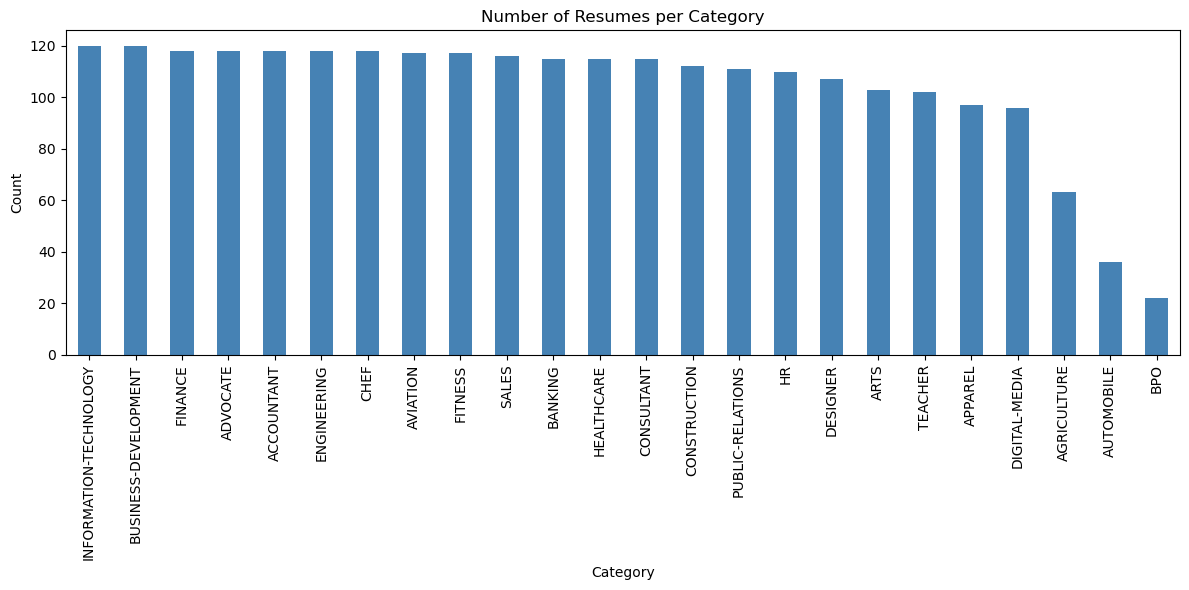

In [2]:
import matplotlib.pyplot as plt
#No. of categories 
category_counts = df['Category'].value_counts()
# print("Total Categories:", df['Category'].nunique())
# print("\nResumes per category:")
# print(category_counts)

plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Resumes per Category')
plt.xlabel('Category')
plt.ylabel('Count')
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [3]:
import re

def clean_resume(text):
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower().strip()
    return text

# This line was commented out! ← that's problem 1
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)
print(f"✅ Cleaned {len(df)} resumes!")

# Filter low sample categories ← this was deleted, that's problem 2
min_samples = 50
category_counts = df['Category'].value_counts()
valid_categories = category_counts[category_counts >= min_samples].index
df_filtered = df[df['Category'].isin(valid_categories)]

print(f"✅ Filtered: {len(df_filtered)} resumes, {df_filtered['Category'].nunique()} categories")

✅ Cleaned 2484 resumes!
✅ Filtered: 2426 resumes, 22 categories


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Use filtered dataset
X_raw = df_filtered['cleaned_resume']
y_raw = df_filtered['Category']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42
)

# Build pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Final Model Accuracy: {accuracy * 100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred))

✅ Final Model Accuracy: 79.84%

Detailed Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.87      0.97      0.92        34
              ADVOCATE       1.00      0.73      0.85        30
           AGRICULTURE       0.83      0.42      0.56        12
               APPAREL       1.00      0.55      0.71        20
                  ARTS       1.00      0.17      0.29        18
              AVIATION       0.76      0.95      0.84        20
               BANKING       0.95      0.72      0.82        25
  BUSINESS-DEVELOPMENT       0.86      0.83      0.84        23
                  CHEF       0.89      0.89      0.89        19
          CONSTRUCTION       0.94      1.00      0.97        16
            CONSULTANT       0.80      0.75      0.77        16
              DESIGNER       0.82      0.96      0.88        24
         DIGITAL-MEDIA       0.76      0.67      0.71        24
           ENGINEERING       0.68      0.85      0.76 

In [5]:
import joblib

# Save the entire pipeline (TF-IDF + Random Forest together)
joblib.dump(pipeline, 'resume_model.pkl')

# Save the categories list
joblib.dump(df_filtered['Category'].unique().tolist(), 'categories.pkl')

print("✅ Model saved as resume_model.pkl")
print("✅ Categories saved as categories.pkl")

# Check file sizes
import os
model_size = os.path.getsize('resume_model.pkl') / (1024 * 1024)
print(f"\n📦 Model size: {model_size:.2f} MB")


✅ Model saved as resume_model.pkl
✅ Categories saved as categories.pkl

📦 Model size: 47.70 MB
